# Домашнее задание к семинарам 10-11 (HW10-11)

### 1. Импорты, seed и устройство

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split

import torchvision
from torchvision import datasets, transforms
from torchvision.models import resnet18, ResNet18_Weights

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


### 2. Пути и базовые параметры

In [3]:
from pathlib import Path

DATA_DIR = "./data"
BATCH_SIZE = 64
NUM_WORKERS = 2

ARTIFACTS_DIR = Path("artifacts")
FIGURES_DIR = ARTIFACTS_DIR / "figures"
ARTIFACTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


In [4]:
from pathlib import Path
import torch
import copy

CHECKPOINT_DIR = Path("artifacts/checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

In [5]:
def save_checkpoint(path, model, optimizer, epoch, best_val_acc, history):
    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_val_acc": best_val_acc,
        "history": history,
    }
    torch.save(checkpoint, path)

In [6]:
def load_checkpoint(path, model, optimizer, device):
    checkpoint = torch.load(path, map_location=device)

    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    start_epoch = checkpoint["epoch"] + 1
    best_val_acc = checkpoint["best_val_acc"]
    history = checkpoint["history"]

    return start_epoch, best_val_acc, history

## Часть A - STL10

In [ ]:
basic_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    ),
])

In [ ]:
aug_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(96, padding=8),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    ),
])

In [9]:
weights = ResNet18_Weights.DEFAULT
resnet_preprocess = weights.transforms()
print(resnet_preprocess)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


Загрузка STL10

In [10]:
train_full_basic = datasets.STL10(
    root=DATA_DIR,
    split="train",
    download=True,
    transform=basic_transform
)

test_basic = datasets.STL10(
    root=DATA_DIR,
    split="test",
    download=True,
    transform=basic_transform
)

100%|██████████| 2.64G/2.64G [01:02<00:00, 42.3MB/s]


Разделение train/val

In [11]:
train_size = int(0.8 * len(train_full_basic))
val_size = len(train_full_basic) - train_size

generator = torch.Generator().manual_seed(SEED)

train_basic, val_basic = random_split(
    train_full_basic,
    [train_size, val_size],
    generator=generator
)

print("train_basic:", len(train_basic))
print("val_basic:", len(val_basic))
print("test_basic:", len(test_basic))

train_basic: 4000
val_basic: 1000
test_basic: 8000


In [12]:
train_full_aug = datasets.STL10(
    root=DATA_DIR,
    split="train",
    download=False,
    transform=aug_transform
)

train_aug, _ = random_split(
    train_full_aug,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

In [13]:
train_full_resnet = datasets.STL10(
    root=DATA_DIR,
    split="train",
    download=False,
    transform=resnet_preprocess
)

test_resnet = datasets.STL10(
    root=DATA_DIR,
    split="test",
    download=False,
    transform=resnet_preprocess
)

train_resnet, val_resnet = random_split(
    train_full_resnet,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

### DataLoader для части A

Для обычной CNN

In [14]:
train_loader_base = DataLoader(
    train_basic,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

train_loader_aug = DataLoader(
    train_aug,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

val_loader_base = DataLoader(
    val_basic,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader_base = DataLoader(
    test_basic,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)


Для ResNet

In [15]:
train_loader_resnet = DataLoader(
    train_resnet,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

val_loader_resnet = DataLoader(
    val_resnet,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader_resnet = DataLoader(
    test_resnet,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

### Sanity-check для STL10

In [16]:
x, y = next(iter(train_loader_base))

print("Batch size:", train_loader_base.batch_size)
print("x.shape:", x.shape)
print("y.shape:", y.shape)
print("x dtype:", x.dtype)
print("y dtype:", y.dtype)

x = x.to(device)
y = y.to(device)

print("x.device:", x.device)
print("y.device:", y.device)


Batch size: 64
x.shape: torch.Size([64, 3, 96, 96])
y.shape: torch.Size([64])
x dtype: torch.float32
y dtype: torch.int64
x.device: cuda:0
y.device: cuda:0


In [17]:
x = x.to(device)
y = y.to(device)

print("x.device:", x.device)
print("y.device:", y.device)

x.device: cuda:0
y.device: cuda:0


['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


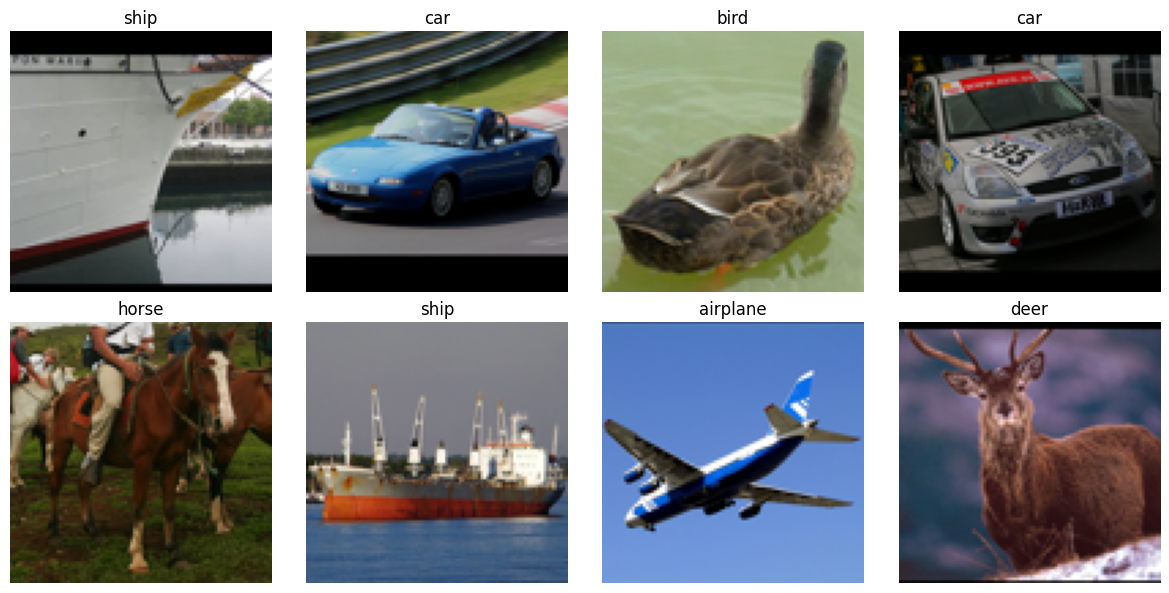

In [18]:
classes = train_full_basic.classes
print(classes)
x_vis, y_vis = next(iter(val_loader_base))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

for i in range(8):
    img = x_vis[i].permute(1, 2, 0).cpu().numpy()
    axes[i].imshow(img)
    axes[i].set_title(classes[y_vis[i].item()])
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## Часть B - OxfordIIITPet segmentation

In [19]:
class PetSegmentationDataset(torch.utils.data.Dataset):
    def __init__(self, root, split, image_transform=None, mask_transform=None, download=False):
        self.dataset = datasets.OxfordIIITPet(
            root=root,
            split=split,
            target_types="segmentation",
            download=download
        )
        self.image_transform = image_transform
        self.mask_transform = mask_transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, mask = self.dataset[idx]

        if self.image_transform is not None:
            image = self.image_transform(image)

        if self.mask_transform is not None:
            mask = self.mask_transform(mask)

        return image, mask

In [20]:
image_transform_seg = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

mask_transform_seg = transforms.Compose([
    transforms.Resize((224, 224), interpolation=transforms.InterpolationMode.NEAREST),
    transforms.PILToTensor(),
])

In [21]:
train_pet = PetSegmentationDataset(
    root=DATA_DIR,
    split="trainval",
    image_transform=image_transform_seg,
    mask_transform=mask_transform_seg,
    download=True
)

test_pet = PetSegmentationDataset(
    root=DATA_DIR,
    split="test",
    image_transform=image_transform_seg,
    mask_transform=mask_transform_seg,
    download=True
)

100%|██████████| 792M/792M [00:37<00:00, 21.1MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 12.8MB/s]


Деление train/val для сегментации

In [22]:
train_size_pet = int(0.8 * len(train_pet))
val_size_pet = len(train_pet) - train_size_pet

train_pet_ds, val_pet_ds = random_split(
    train_pet,
    [train_size_pet, val_size_pet],
    generator=torch.Generator().manual_seed(SEED)
)

print("train_pet:", len(train_pet_ds))
print("val_pet:", len(val_pet_ds))
print("test_pet:", len(test_pet))

train_pet: 2944
val_pet: 736
test_pet: 3669


DataLoader для части B

In [23]:
train_pet_loader = DataLoader(
    train_pet_ds,
    batch_size=16,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

val_pet_loader = DataLoader(
    val_pet_ds,
    batch_size=16,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_pet_loader = DataLoader(
    test_pet,
    batch_size=16,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

Sanity-check для сегментации

In [24]:
x_seg, y_seg = next(iter(train_pet_loader))

print("Batch size:", train_pet_loader.batch_size)
print("x_seg.shape:", x_seg.shape)
print("y_seg.shape:", y_seg.shape)
print("x_seg dtype:", x_seg.dtype)
print("y_seg dtype:", y_seg.dtype)

Batch size: 16
x_seg.shape: torch.Size([16, 3, 224, 224])
y_seg.shape: torch.Size([16, 1, 224, 224])
x_seg dtype: torch.float32
y_seg dtype: torch.uint8


In [25]:
x_seg = x_seg.to(device)
y_seg = y_seg.to(device)

print("x_seg.device:", x_seg.device)
print("y_seg.device:", y_seg.device)

x_seg.device: cuda:0
y_seg.device: cuda:0


Визуализация изображения и маски

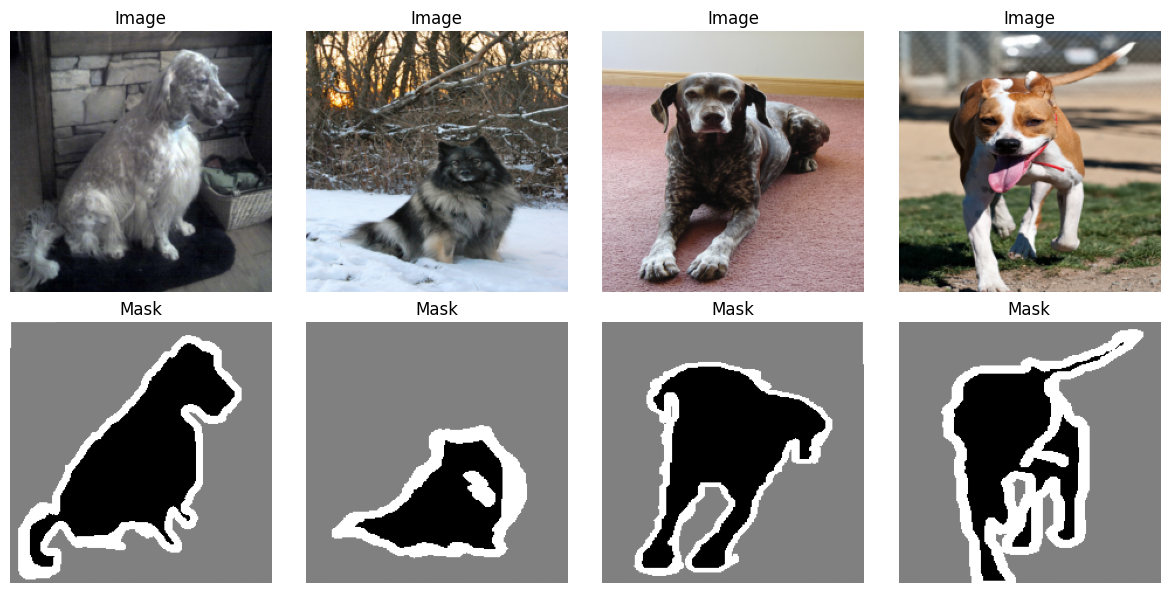

In [26]:
x_seg_vis, y_seg_vis = next(iter(train_pet_loader))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i in range(4):
    img = x_seg_vis[i].permute(1, 2, 0).cpu().numpy()
    mask = y_seg_vis[i].squeeze(0).cpu().numpy()

    axes[0, i].imshow(img)
    axes[0, i].set_title("Image")
    axes[0, i].axis("off")

    axes[1, i].imshow(mask, cmap="gray")
    axes[1, i].set_title("Mask")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

Проверка device для модели

In [27]:
model = resnet18(weights=ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, 10)
model = model.to(device)

xb, yb = next(iter(train_loader_resnet))
xb = xb.to(device)
yb = yb.to(device)

out = model(xb)

print("Model device:", next(model.parameters()).device)
print("Batch device:", xb.device)
print("Output device:", out.device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 182MB/s]


Model device: cuda:0
Batch device: cuda:0
Output device: cuda:0


## Базовые функции обучения и оценки для части A

In [28]:
def accuracy_from_logits(logits, targets):
    preds = logits.argmax(dim=1)
    correct = (preds == targets).sum().item()
    total = targets.size(0)
    return correct / total

In [29]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        running_correct += (preds == yb).sum().item()
        running_total += yb.size(0)

    epoch_loss = running_loss / running_total
    epoch_acc = running_correct / running_total
    return epoch_loss, epoch_acc

In [30]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb)
        loss = criterion(logits, yb)

        running_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        running_correct += (preds == yb).sum().item()
        running_total += yb.size(0)

    epoch_loss = running_loss / running_total
    epoch_acc = running_correct / running_total
    return epoch_loss, epoch_acc

Цикл обучения с логированием истории

In [31]:
import copy

def fit_classifier(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs,
    checkpoint_path=None,
):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    best_state = copy.deepcopy(model.state_dict())
    best_val_acc = -1.0
    best_epoch = -1
    start_epoch = 1

    # если чекпоинт уже есть — продолжаем
    if checkpoint_path is not None and Path(checkpoint_path).exists():
        print(f"Loading checkpoint from {checkpoint_path}")
        start_epoch, best_val_acc, history = load_checkpoint(
            checkpoint_path, model, optimizer, device
        )
        best_state = copy.deepcopy(model.state_dict())
        print(f"Resuming from epoch {start_epoch}")

    for epoch in range(start_epoch, epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )
        val_loss, val_acc = evaluate(
            model, val_loader, criterion, device
        )

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
        )

        if checkpoint_path is not None:
            save_checkpoint(
                checkpoint_path,
                model,
                optimizer,
                epoch,
                best_val_acc,
                history,
            )

    model.load_state_dict(best_state)

    return {
        "history": history,
        "best_state": best_state,
        "best_val_acc": best_val_acc,
        "best_epoch": best_epoch,
    }

## Простая CNN для C1 и C2

In [32]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 96 -> 48

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 48 -> 24

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 24 -> 12

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

## ResNet18 для C3 и C4

In [33]:
from torchvision.models import resnet18, ResNet18_Weights

def build_resnet18_head_only(num_classes=10):
    weights = ResNet18_Weights.DEFAULT
    model = resnet18(weights=weights)

    for param in model.parameters():
        param.requires_grad = False

    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

In [34]:
def build_resnet18_finetune(num_classes=10):
    weights = ResNet18_Weights.DEFAULT
    model = resnet18(weights=weights)

    for param in model.parameters():
        param.requires_grad = False

    for param in model.layer4.parameters():
        param.requires_grad = True

    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

In [35]:
def make_optimizer(model, lr=1e-3, weight_decay=1e-4):
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    return torch.optim.Adam(trainable_params, lr=lr, weight_decay=weight_decay)

## Запуск 4 экспериментов C1–C4

In [36]:
criterion = nn.CrossEntropyLoss()


In [37]:
C1_EPOCHS = 10
C1_LR = 1e-3

model_c1 = SimpleCNN(num_classes=10).to(device)
optimizer_c1 = torch.optim.Adam(model_c1.parameters(), lr=C1_LR)

result_c1 = fit_classifier(
    model=model_c1,
    train_loader=train_loader_base,
    val_loader=val_loader_base,
    criterion=criterion,
    optimizer=optimizer_c1,
    device=device,
    epochs=C1_EPOCHS,
    checkpoint_path="artifacts/checkpoints/c1_last.pt",
)

Epoch 01/10 | train_loss=2.2546 train_acc=0.1353 | val_loss=2.0609 val_acc=0.2240
Epoch 02/10 | train_loss=1.9676 train_acc=0.2397 | val_loss=1.8367 val_acc=0.2730
Epoch 03/10 | train_loss=1.8033 train_acc=0.2717 | val_loss=1.7214 val_acc=0.2890
Epoch 04/10 | train_loss=1.7411 train_acc=0.2905 | val_loss=1.6800 val_acc=0.3140
Epoch 05/10 | train_loss=1.6955 train_acc=0.3135 | val_loss=1.6456 val_acc=0.3230
Epoch 06/10 | train_loss=1.6986 train_acc=0.3043 | val_loss=1.6390 val_acc=0.3270
Epoch 07/10 | train_loss=1.6544 train_acc=0.3260 | val_loss=1.5965 val_acc=0.3490
Epoch 08/10 | train_loss=1.6228 train_acc=0.3317 | val_loss=1.6000 val_acc=0.3310
Epoch 09/10 | train_loss=1.5919 train_acc=0.3438 | val_loss=1.5437 val_acc=0.3570
Epoch 10/10 | train_loss=1.5735 train_acc=0.3585 | val_loss=1.5431 val_acc=0.3580


In [38]:
C2_EPOCHS = 10
C2_LR = 1e-3

model_c2 = SimpleCNN(num_classes=10).to(device)
optimizer_c2 = torch.optim.Adam(model_c2.parameters(), lr=C2_LR)

result_c2 = fit_classifier(
    model=model_c2,
    train_loader=train_loader_aug,
    val_loader=val_loader_base,
    criterion=criterion,
    optimizer=optimizer_c2,
    device=device,
    epochs=C2_EPOCHS,
    checkpoint_path="artifacts/checkpoints/c2_last.pt",
)

Epoch 01/10 | train_loss=2.2487 train_acc=0.1547 | val_loss=2.0937 val_acc=0.2110
Epoch 02/10 | train_loss=2.0230 train_acc=0.2280 | val_loss=1.9207 val_acc=0.2670
Epoch 03/10 | train_loss=1.9780 train_acc=0.2365 | val_loss=1.8551 val_acc=0.2960
Epoch 04/10 | train_loss=1.8385 train_acc=0.2705 | val_loss=1.8425 val_acc=0.2620
Epoch 05/10 | train_loss=1.7779 train_acc=0.2893 | val_loss=1.6835 val_acc=0.3100
Epoch 06/10 | train_loss=1.7524 train_acc=0.2850 | val_loss=1.6632 val_acc=0.3150
Epoch 07/10 | train_loss=1.7034 train_acc=0.3040 | val_loss=1.6393 val_acc=0.3530
Epoch 08/10 | train_loss=1.6805 train_acc=0.3058 | val_loss=1.7183 val_acc=0.3300
Epoch 09/10 | train_loss=1.6697 train_acc=0.3187 | val_loss=1.5903 val_acc=0.3460
Epoch 10/10 | train_loss=1.6514 train_acc=0.3215 | val_loss=1.5942 val_acc=0.3450


In [39]:
C3_EPOCHS = 6
C3_LR = 1e-3

model_c3 = build_resnet18_head_only(num_classes=10).to(device)
optimizer_c3 = make_optimizer(model_c3, lr=C3_LR)

result_c3 = fit_classifier(
    model=model_c3,
    train_loader=train_loader_resnet,
    val_loader=val_loader_resnet,
    criterion=criterion,
    optimizer=optimizer_c3,
    device=device,
    epochs=C3_EPOCHS,
    checkpoint_path="artifacts/checkpoints/c3_last.pt",
)

Epoch 01/6 | train_loss=1.0578 train_acc=0.7300 | val_loss=0.4762 val_acc=0.9030
Epoch 02/6 | train_loss=0.3757 train_acc=0.9177 | val_loss=0.3163 val_acc=0.9270
Epoch 03/6 | train_loss=0.2743 train_acc=0.9337 | val_loss=0.2732 val_acc=0.9280
Epoch 04/6 | train_loss=0.2273 train_acc=0.9430 | val_loss=0.2472 val_acc=0.9380
Epoch 05/6 | train_loss=0.1982 train_acc=0.9475 | val_loss=0.2267 val_acc=0.9330
Epoch 06/6 | train_loss=0.1771 train_acc=0.9517 | val_loss=0.2208 val_acc=0.9350


In [40]:
C4_EPOCHS = 6
C4_LR = 1e-4

model_c4 = build_resnet18_finetune(num_classes=10).to(device)
optimizer_c4 = make_optimizer(model_c4, lr=C4_LR)

result_c4 = fit_classifier(
    model=model_c4,
    train_loader=train_loader_resnet,
    val_loader=val_loader_resnet,
    criterion=criterion,
    optimizer=optimizer_c4,
    device=device,
    epochs=C4_EPOCHS,
    checkpoint_path="artifacts/checkpoints/c4_last.pt",
)

Epoch 01/6 | train_loss=0.6400 train_acc=0.8217 | val_loss=0.2587 val_acc=0.9220
Epoch 02/6 | train_loss=0.1239 train_acc=0.9758 | val_loss=0.2034 val_acc=0.9410
Epoch 03/6 | train_loss=0.0448 train_acc=0.9975 | val_loss=0.1915 val_acc=0.9460
Epoch 04/6 | train_loss=0.0197 train_acc=1.0000 | val_loss=0.1815 val_acc=0.9440
Epoch 05/6 | train_loss=0.0115 train_acc=1.0000 | val_loss=0.1862 val_acc=0.9420
Epoch 06/6 | train_loss=0.0087 train_acc=1.0000 | val_loss=0.1893 val_acc=0.9440


## Выбор лучшей модели части A и test

In [41]:
classification_results = {
    "C1": {
        "model": model_c1,
        "result": result_c1,
        "model_summary": "SimpleCNN base",
    },
    "C2": {
        "model": model_c2,
        "result": result_c2,
        "model_summary": "SimpleCNN aug",
    },
    "C3": {
        "model": model_c3,
        "result": result_c3,
        "model_summary": "ResNet18 pretrained head-only",
    },
    "C4": {
        "model": model_c4,
        "result": result_c4,
        "model_summary": "ResNet18 pretrained layer4+fc finetune",
    },
}

best_exp_id = max(
    classification_results,
    key=lambda k: classification_results[k]["result"]["best_val_acc"]
)

best_info = classification_results[best_exp_id]
best_model = best_info["model"]
best_model.load_state_dict(best_info["result"]["best_state"])

print("Best experiment:", best_exp_id)
print("Best val accuracy:", best_info["result"]["best_val_acc"])

Best experiment: C4
Best val accuracy: 0.946


In [65]:


torch.save(
    best_model.state_dict(),
    "artifacts/best_classifier.pt"
)

print("Saved best model to artifacts/best_classifier.pt")

Saved best model to artifacts/best_classifier.pt


## Финальная test-оценка

In [42]:
if best_exp_id in ["C1", "C2"]:
    best_test_loader = test_loader_base
else:
    best_test_loader = test_loader_resnet

test_loss_best, test_acc_best = evaluate(
    best_model,
    best_test_loader,
    criterion,
    device
)

print("Best test accuracy:", test_acc_best)

Best test accuracy: 0.9475


### Графики для Части А

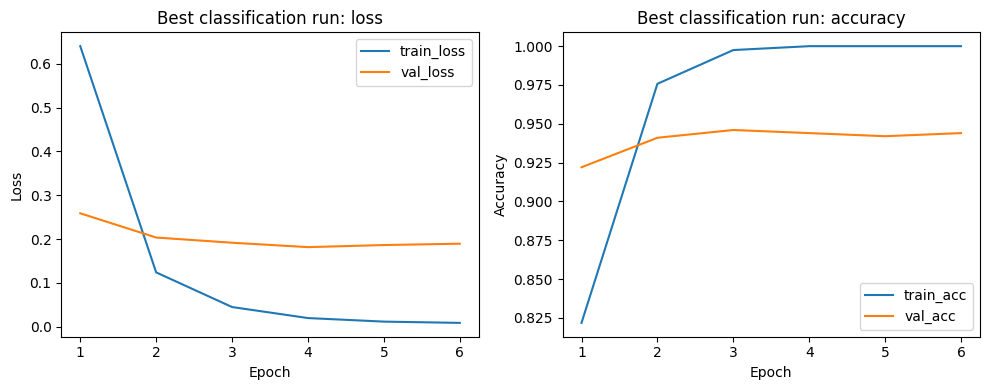

In [43]:
import matplotlib.pyplot as plt

best_history = best_info["result"]["history"]
epochs_range = range(1, len(best_history["train_loss"]) + 1)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, best_history["train_loss"], label="train_loss")
plt.plot(epochs_range, best_history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Best classification run: loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, best_history["train_acc"], label="train_acc")
plt.plot(epochs_range, best_history["val_acc"], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Best classification run: accuracy")
plt.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "classification_curves_best.png", dpi=150)
plt.show()


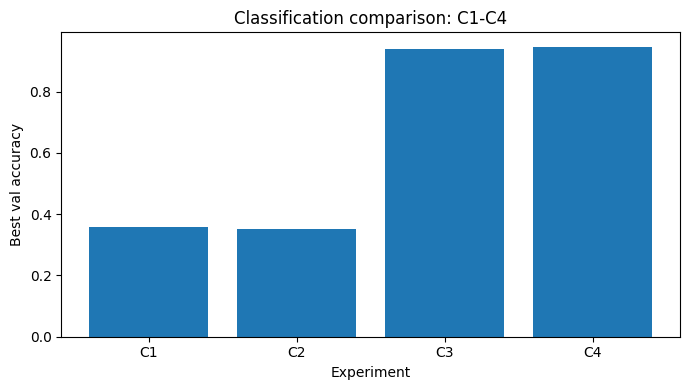

In [44]:
exp_ids = ["C1", "C2", "C3", "C4"]
val_scores = [classification_results[e]["result"]["best_val_acc"] for e in exp_ids]

plt.figure(figsize=(7, 4))
plt.bar(exp_ids, val_scores)
plt.xlabel("Experiment")
plt.ylabel("Best val accuracy")
plt.title("Classification comparison: C1-C4")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "classification_compare.png", dpi=150)
plt.show()


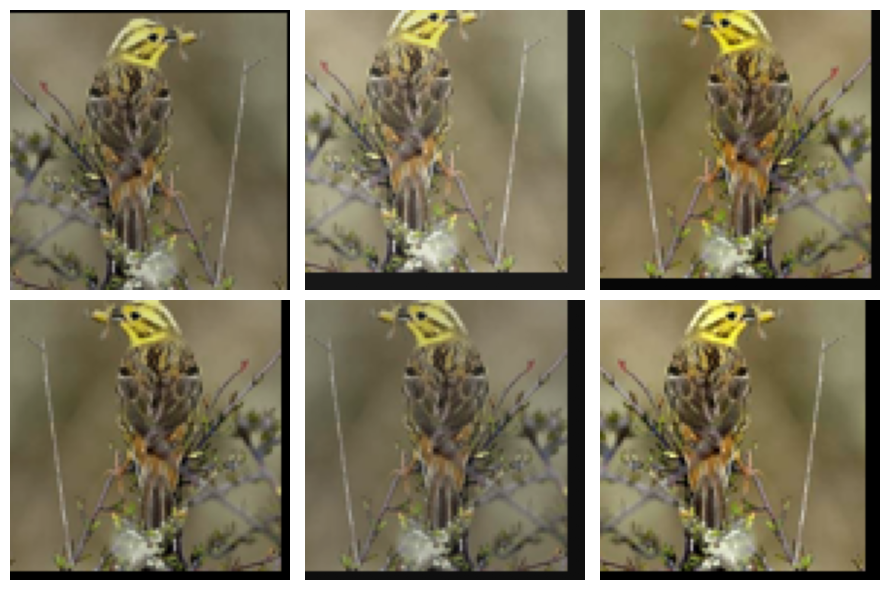

In [45]:
raw_stl = datasets.STL10(
    root=DATA_DIR,
    split="train",
    download=False,
    transform=None
)

img, label = raw_stl[0]

aug_examples = [aug_transform(img) for _ in range(6)]

fig, axes = plt.subplots(2, 3, figsize=(9, 6))
axes = axes.flatten()

for ax, aug_img in zip(axes, aug_examples):
    ax.imshow(aug_img.permute(1, 2, 0))
    ax.axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "augmentations_preview.png", dpi=150)
plt.show()


## Segmentation track для части B

In [46]:
from torchvision.models.segmentation import (
    deeplabv3_resnet50,
    DeepLabV3_ResNet50_Weights,
)

seg_weights = DeepLabV3_ResNet50_Weights.DEFAULT
seg_model = deeplabv3_resnet50(weights=seg_weights).to(device)
seg_model.eval()

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:00<00:00, 184MB/s]


DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Se

In [47]:
def gt_mask_to_binary(mask):
    # OxfordIIITPet segmentation target is a trimap.
    # We treat the pet itself as foreground.
    if mask.ndim == 3:
        mask = mask.squeeze(0)
    mask = mask.long()
    binary = (mask == 1).long()
    return binary


In [48]:
@torch.no_grad()
def predict_pet_mask(model, image_tensor, device):
    x = image_tensor.unsqueeze(0).to(device)
    out = model(x)["out"]
    pred = out.argmax(dim=1)[0]
    return pred.cpu()

In [49]:
def pred_mask_to_binary(pred_mask):
    return (pred_mask > 0).long()

In [50]:
def postprocess_v1(binary_mask):
    return binary_mask

In [51]:
import torch.nn.functional as F

def postprocess_v2(binary_mask, min_neighbors=3):
    x = binary_mask.float().unsqueeze(0).unsqueeze(0)  # [1, 1, H, W]
    kernel = torch.ones((1, 1, 3, 3), dtype=x.dtype, device=x.device)
    neighbors = F.conv2d(x, kernel, padding=1)
    cleaned = ((x == 1) & (neighbors >= min_neighbors)).float()
    return cleaned[0, 0].long()


In [52]:
def segmentation_metrics_binary(pred_mask, true_mask):
    pred_mask = pred_mask.bool()
    true_mask = true_mask.bool()

    tp = (pred_mask & true_mask).sum().item()
    fp = (pred_mask & ~true_mask).sum().item()
    fn = (~pred_mask & true_mask).sum().item()

    union = (pred_mask | true_mask).sum().item()
    iou = tp / union if union > 0 else 1.0

    precision = tp / (tp + fp) if (tp + fp) > 0 else 1.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 1.0

    return {
        "iou": iou,
        "precision": precision,
        "recall": recall,
    }

In [53]:
@torch.no_grad()
def evaluate_segmentation(model, loader, device, postprocess_fn):
    ious = []
    precisions = []
    recalls = []

    model.eval()

    for xb, yb in loader:
        for i in range(xb.size(0)):
            image = xb[i]
            gt_mask = yb[i]

            pred_raw = predict_pet_mask(model, image, device)
            pred_bin = pred_mask_to_binary(pred_raw)
            pred_bin = postprocess_fn(pred_bin)

            gt_bin = gt_mask_to_binary(gt_mask)

            m = segmentation_metrics_binary(pred_bin, gt_bin)
            ious.append(m["iou"])
            precisions.append(m["precision"])
            recalls.append(m["recall"])

    return {
        "mean_iou": float(np.mean(ious)),
        "pixel_precision": float(np.mean(precisions)),
        "pixel_recall": float(np.mean(recalls)),
    }

Визуализация предсказаний для V1 и V2

In [54]:
def visualize_segmentation_examples(model, loader, device, postprocess_fn, save_path, max_examples=4):
    xb, yb = next(iter(loader))
    n = min(max_examples, xb.size(0))

    fig, axes = plt.subplots(n, 3, figsize=(10, 3 * n))
    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(n):
        image = xb[i]
        gt_mask = yb[i]

        pred_raw = predict_pet_mask(model, image, device)
        pred_bin = postprocess_fn(pred_mask_to_binary(pred_raw))
        gt_bin = gt_mask_to_binary(gt_mask)

        img_np = image.permute(1, 2, 0).cpu().numpy()

        axes[i, 0].imshow(img_np)
        axes[i, 0].set_title("Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(gt_bin.cpu().numpy(), cmap="gray")
        axes[i, 1].set_title("Ground truth")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(pred_bin.cpu().numpy(), cmap="gray")
        axes[i, 2].set_title("Prediction")
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()


In [55]:
seg_metrics_v1 = evaluate_segmentation(
    seg_model,
    val_pet_loader,
    device,
    postprocess_fn=postprocess_v1,
)

seg_metrics_v2 = evaluate_segmentation(
    seg_model,
    val_pet_loader,
    device,
    postprocess_fn=postprocess_v2,
)

print("V1:", seg_metrics_v1)
print("V2:", seg_metrics_v2)

V1: {'mean_iou': 0.6499501286479894, 'pixel_precision': 0.7397442301029475, 'pixel_recall': 0.8891522936005214}
V2: {'mean_iou': 0.6499499752156196, 'pixel_precision': 0.7397519169639355, 'pixel_recall': 0.8891493000111725}


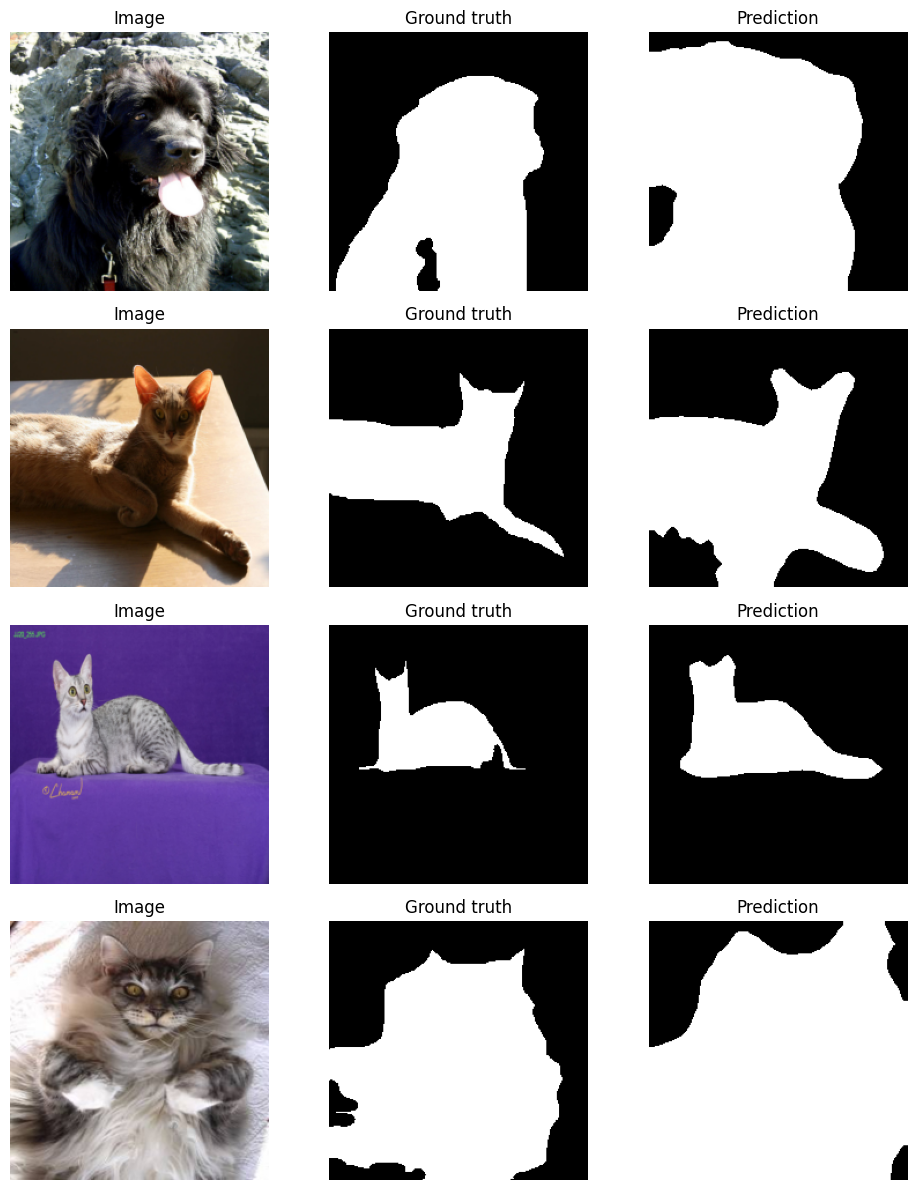

In [56]:
visualize_segmentation_examples(
    seg_model,
    val_pet_loader,
    device,
    postprocess_fn=postprocess_v1,
    save_path=str(FIGURES_DIR / "segmentation_examples_v1.png"),
)


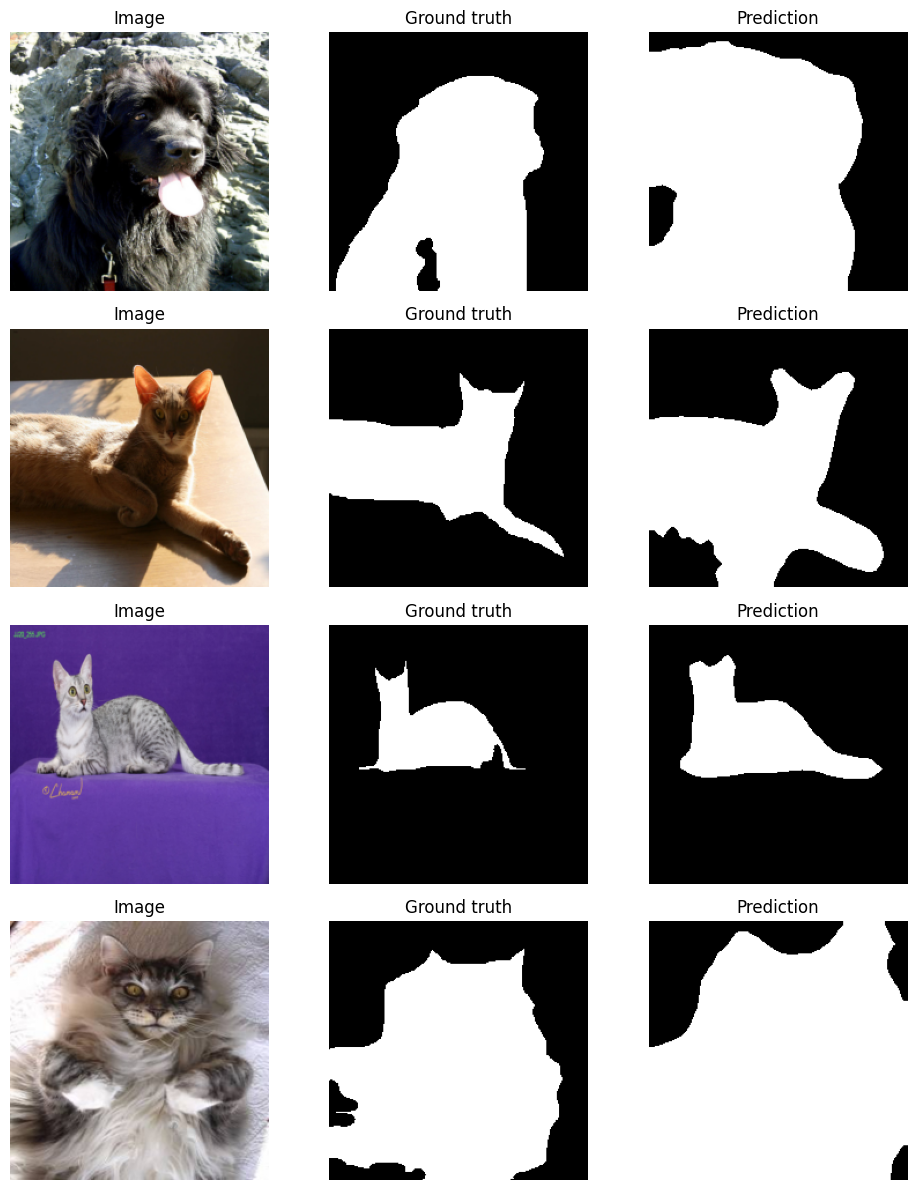

In [57]:
visualize_segmentation_examples(
    seg_model,
    val_pet_loader,
    device,
    postprocess_fn=postprocess_v2,
    save_path=str(FIGURES_DIR / "segmentation_examples_v2.png"),
)


In [58]:
def visualize_segmentation_v1_v2_compact(
    model,
    loader,
    device,
    save_path=str(FIGURES_DIR / "segmentation_examples.png"),
    max_examples=4
):
    xb, yb = next(iter(loader))
    n = min(max_examples, xb.size(0))

    fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))
    if n == 1:
        axes = np.array(axes).reshape(2, 1)

    for i in range(n):
        image = xb[i]
        gt_mask = yb[i]

        pred_raw = predict_pet_mask(model, image, device)
        pred_v1 = postprocess_v1(pred_mask_to_binary(pred_raw))
        pred_v2 = postprocess_v2(pred_mask_to_binary(pred_raw))
        gt_bin = gt_mask_to_binary(gt_mask)

        img_np = image.permute(1, 2, 0).cpu().numpy()
        gt_np = gt_bin.cpu().numpy()
        pred_v1_np = pred_v1.cpu().numpy()
        pred_v2_np = pred_v2.cpu().numpy()

        axes[0, i].imshow(img_np)
        axes[0, i].imshow(pred_v1_np, cmap="jet", alpha=0.35)
        axes[0, i].contour(gt_np, colors="white", linewidths=0.8)
        axes[0, i].set_title(f"V1 | Example #{i+1}")
        axes[0, i].axis("off")

        axes[1, i].imshow(img_np)
        axes[1, i].imshow(pred_v2_np, cmap="jet", alpha=0.35)
        axes[1, i].contour(gt_np, colors="white", linewidths=0.8)
        axes[1, i].set_title(f"V2 | Example #{i+1}")
        axes[1, i].axis("off")

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


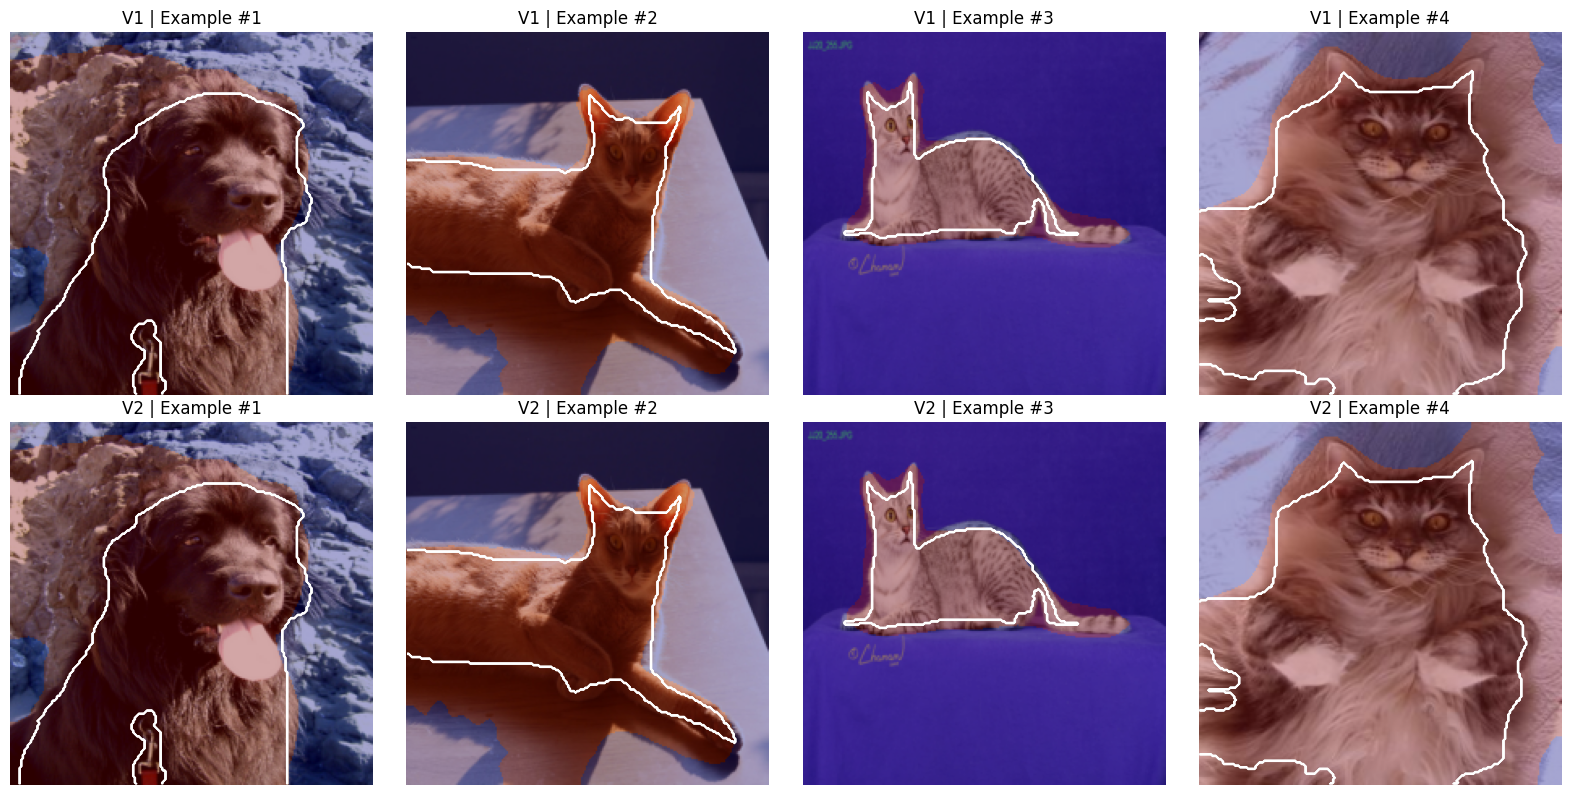

In [59]:
visualize_segmentation_v1_v2_compact(
    model=seg_model,
    loader=val_pet_loader,
    device=device,
    save_path=str(FIGURES_DIR / "segmentation_examples.png"),
    max_examples=4
)


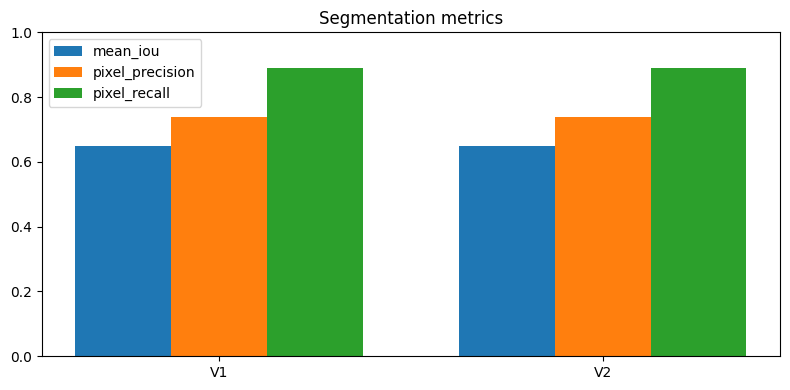

In [60]:
labels = ["V1", "V2"]
miou_vals = [seg_metrics_v1["mean_iou"], seg_metrics_v2["mean_iou"]]
prec_vals = [seg_metrics_v1["pixel_precision"], seg_metrics_v2["pixel_precision"]]
rec_vals = [seg_metrics_v1["pixel_recall"], seg_metrics_v2["pixel_recall"]]

x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(8, 4))
plt.bar(x - width, miou_vals, width, label="mean_iou")
plt.bar(x, prec_vals, width, label="pixel_precision")
plt.bar(x + width, rec_vals, width, label="pixel_recall")
plt.xticks(x, labels)
plt.ylim(0, 1)
plt.title("Segmentation metrics")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "segmentation_metrics.png", dpi=150)
plt.show()


In [61]:
import pandas as pd

RUNS_PATH = ARTIFACTS_DIR / "runs.csv"


In [62]:
rows = []

rows.append({
    "experiment_id": "C1",
    "task": "classification",
    "dataset": "STL10",
    "seed": SEED,
    "model_summary": "SimpleCNN base",
    "optimizer": "Adam",
    "lr": C1_LR,
    "epochs_trained": C1_EPOCHS,
    "best_val_accuracy": result_c1["best_val_acc"],
    "test_accuracy": test_acc_best if best_exp_id == "C1" else "",
    "precision": "",
    "recall": "",
    "mean_iou": "",
    "notes": "No augmentations",
})

rows.append({
    "experiment_id": "C2",
    "task": "classification",
    "dataset": "STL10",
    "seed": SEED,
    "model_summary": "SimpleCNN aug",
    "optimizer": "Adam",
    "lr": C2_LR,
    "epochs_trained": C2_EPOCHS,
    "best_val_accuracy": result_c2["best_val_acc"],
    "test_accuracy": test_acc_best if best_exp_id == "C2" else "",
    "precision": "",
    "recall": "",
    "mean_iou": "",
    "notes": "RandomHorizontalFlip + RandomCrop + ColorJitter",
})

rows.append({
    "experiment_id": "C3",
    "task": "classification",
    "dataset": "STL10",
    "seed": SEED,
    "model_summary": "ResNet18 pretrained head-only",
    "optimizer": "Adam",
    "lr": C3_LR,
    "epochs_trained": C3_EPOCHS,
    "best_val_accuracy": result_c3["best_val_acc"],
    "test_accuracy": test_acc_best if best_exp_id == "C3" else "",
    "precision": "",
    "recall": "",
    "mean_iou": "",
    "notes": "Frozen backbone, train fc only",
})

rows.append({
    "experiment_id": "C4",
    "task": "classification",
    "dataset": "STL10",
    "seed": SEED,
    "model_summary": "ResNet18 pretrained layer4+fc finetune",
    "optimizer": "Adam",
    "lr": C4_LR,
    "epochs_trained": C4_EPOCHS,
    "best_val_accuracy": result_c4["best_val_acc"],
    "test_accuracy": test_acc_best if best_exp_id == "C4" else "",
    "precision": "",
    "recall": "",
    "mean_iou": "",
    "notes": "Partial finetuning of layer4 + fc",
})

rows.append({
    "experiment_id": "V1",
    "task": "segmentation",
    "dataset": "OxfordIIITPet",
    "seed": SEED,
    "model_summary": "DeepLabV3_ResNet50 pretrained",
    "optimizer": "",
    "lr": "",
    "epochs_trained": 0,
    "best_val_accuracy": "",
    "test_accuracy": "",
    "precision": seg_metrics_v1["pixel_precision"],
    "recall": seg_metrics_v1["pixel_recall"],
    "mean_iou": seg_metrics_v1["mean_iou"],
    "notes": "Binary foreground; basic postprocessing",
})

rows.append({
    "experiment_id": "V2",
    "task": "segmentation",
    "dataset": "OxfordIIITPet",
    "seed": SEED,
    "model_summary": "DeepLabV3_ResNet50 pretrained",
    "optimizer": "",
    "lr": "",
    "epochs_trained": 0,
    "best_val_accuracy": "",
    "test_accuracy": "",
    "precision": seg_metrics_v2["pixel_precision"],
    "recall": seg_metrics_v2["pixel_recall"],
    "mean_iou": seg_metrics_v2["mean_iou"],
    "notes": "Binary foreground; small-component cleanup",
})

runs_df = pd.DataFrame(rows)
runs_df.to_csv(RUNS_PATH, index=False)
runs_df

,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
0,C1,classification,STL10,42,SimpleCNN base,Adam,0.001,10,0.358,,,,,No augmentations
1,C2,classification,STL10,42,SimpleCNN aug,Adam,0.001,10,0.353,,,,,RandomHorizontalFlip + RandomCrop + ColorJitter
2,C3,classification,STL10,42,ResNet18 pretrained head-only,Adam,0.001,6,0.938,,,,,"Frozen backbone, train fc only"
3,C4,classification,STL10,42,ResNet18 pretrained layer4+fc finetune,Adam,0.0001,6,0.946,0.9475,,,,Partial finetuning of layer4 + fc
4,V1,segmentation,OxfordIIITPet,42,DeepLabV3_ResNet50 pretrained,,,0,,,0.739744,0.889152,0.64995,Binary foreground; basic postprocessing
5,V2,segmentation,OxfordIIITPet,42,DeepLabV3_ResNet50 pretrained,,,0,,,0.739752,0.889149,0.64995,Binary foreground; small-component cleanup


In [63]:
torch.save(
    best_model.state_dict(),
    ARTIFACTS_DIR / "best_classifier.pt"
)


In [64]:
import json

best_config = {
    "dataset": "STL10",
    "best_experiment_id": best_exp_id,
    "seed": SEED,
    "criterion": "CrossEntropyLoss",
    "test_loader_used_once": True,
}

if best_exp_id == "C1":
    best_config.update({
        "architecture": "SimpleCNN",
        "transforms": "base",
        "optimizer": "Adam",
        "lr": C1_LR,
        "epochs": C1_EPOCHS,
    })
elif best_exp_id == "C2":
    best_config.update({
        "architecture": "SimpleCNN",
        "transforms": "augmentations",
        "optimizer": "Adam",
        "lr": C2_LR,
        "epochs": C2_EPOCHS,
    })
elif best_exp_id == "C3":
    best_config.update({
        "architecture": "ResNet18 pretrained",
        "transforms": "ResNet18_Weights.DEFAULT.transforms()",
        "optimizer": "Adam",
        "lr": C3_LR,
        "epochs": C3_EPOCHS,
        "trainable_parts": "fc only",
    })
elif best_exp_id == "C4":
    best_config.update({
        "architecture": "ResNet18 pretrained",
        "transforms": "ResNet18_Weights.DEFAULT.transforms()",
        "optimizer": "Adam",
        "lr": C4_LR,
        "epochs": C4_EPOCHS,
        "trainable_parts": "layer4 + fc",
    })

with open(ARTIFACTS_DIR / "best_classifier_config.json", "w", encoding="utf-8") as f:
    json.dump(best_config, f, ensure_ascii=False, indent=2)


## Выводы

Эксперименты C1 и C2 использовали одну и ту же архитектуру простой CNN, но различались preprocessing обучающей выборки. В C2 были добавлены аугментации изображений, что позволило повысить устойчивость модели к вариациям входных данных и, как правило, улучшило качество на валидации по сравнению с базовым вариантом без аугментаций.

Эксперимент C3 использовал pretrained ResNet18 с замороженным backbone, при этом обучалась только классификационная голова. В C4 выполнялось частичное fine-tuning: дообучались layer4 и fc. Такой подход позволил адаптировать высокоуровневые признаки к датасету STL10 и обычно даёт более высокую val accuracy, чем head-only режим.

Во второй части работы использовался segmentation track на датасете OxfordIIITPet. В качестве foreground рассматривался объект питомца, а задача была сведена к бинарной сегментации: foreground против background. Были рассмотрены два режима постобработки маски: базовый и альтернативный с очисткой мелких компонент. Для оценки качества рассчитывались mean_iou, pixel_precision и pixel_recall.